# $\text{Taller - Regresión Lineal Múltiple}$
##$\text{Facebook: Predicción de Interacciones Totales}$


---


## $\text{Tabla de contenido:}$
0. $\text{Importar Librerías}$
1. $\text{Regresión Lineal Múltiple}$
2. $\text{Comprendiendo los Datos}$
   - Descripción de Variables
   - Carga de Datos
   - Limpieza de los Datos
3. $\text{Visualización de los Datos usando Gráficos}$
   - Matriz de Correlación
   - Gráfico de Dispersión
   - Gráfico de Violín
   - Gráfico de Líneas
5. $\text{Preparación de X e y}$
6. $\text{División de los Datos en Conjuntos de Entrenamiento y Prueba}$
7. $\text{Entrenamiento del Modelo}$
8. $\text{Cálculo de Coeficientes}$
9. $\text{Predicciones y Evaluación del Modelo}$
10. $\text{Conclusiones}$

## $\text{0. Importar Librerías}$


In [ ]:
# Importar librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## $\text{1. Regresión Lineal Múltiple}$
La regresión lineal múltiple se utiliza cuando se quiere predecir el valor de una variable dependiente en **función de varias variables** independientes. En este caso, predeciremos el **`total de interacciones`** en publicaciones de redes sociales basándonos en atributos como `Page total likes`, `Category`, `Paid`, y otros factores.

**Pregunta orientadora:** ¿Qué ventajas ofrece el uso de múltiples variables para predecir las interacciones en una publicación?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## $\text{2. Comprendiendo los Datos}$


### Descripción de las variables:
A continuación se detallan las columnas del conjunto de datos y su significado:

* `Page total likes`: Número total de "me gusta" en la página.
* `Type`: Tipo de publicación (e.g., Foto, Estado, Enlace).
* `Category`: Categoría de la publicación (numérica).
* `Post Month`: Mes de la publicación.
* `Post Weekday`: Día de la semana de la publicación.
* `Post Hour`: Hora de la publicación.
* `Paid`: Indicador de si la publicación fue pagada (1 si es pagada, 0 si no).
* `Lifetime Post Total Reach`: Alcance total de la publicación (número de personas que vieron la publicación).
* `Lifetime Post Total Impressions`: Impresiones totales de la publicación.
* `Lifetime Engaged Users`: Número de usuarios comprometidos con la publicación (comentaron, compartieron, le dieron "me gusta").
* `Lifetime Post Consumers`: Número de usuarios que interactuaron con la publicación.
* `Lifetime Post Consumptions`: Número total de interacciones en la publicación.
* `Lifetime Post Impressions by people who have liked your Page`: Impresiones de la publicación por personas que ya han dado "me gusta" a la página.
* `Lifetime Post reach by people who like your Page`: Alcance de la publicación por personas que ya han dado "me gusta" a la página.
* `Lifetime People who have liked your Page and engaged with your post`: Número de personas que han dado "me gusta" a la página y han interactuado con la publicación.
* `comment`: Número de comentarios en la publicación.
* `like`: Número de "me gusta" en la publicación.
* `share`: Número de veces que se compartió la publicación.
* **`Total Interactions`**: Total de interacciones (comentarios + "me gusta" + compartir).

**Pregunta orientadora:** ¿Qué columnas crees que tienen la mayor influencia sobre el número total de interacciones?


### Carga de datos:

Recordar que por defecto se espera un separador de **','** en pd.read, pero si hay otro hay que especificarlo...

In [ ]:
# Cargar el dataset

data = pd.read_csv('/content/drive/MyDrive/UNAL/Semestre III/ML/Datas/Facebook.csv', sep = ';')

### Limpieza de los Datos

Verifique si hay valores faltantes y si hay haga las imputaciones necesarias.

In [ ]:
# Verificación de valores faltantes
data.info()

# Revisión de primeros datos
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393


In [ ]:
# Como vemos que hay columnas muy largas cambiamos sus nombres

# Renombrar las columnas
data.columns = [
    'TotalLikes', 'PostType', 'Category', 'PostMonth', 'PostWeekday', 'PostHour', 'Paid',
    'TotalReach', 'TotalImpressions', 'EngagedUsers', 'PostConsumers', 'PostConsumptions',
    'ImpressionsLikedPage', 'ReachLikedPage', 'LikedAndEngaged', 'Comments', 'Likes', 'Shares', 'TotalInteractions'
]

In [ ]:
data.isna().sum()

,0
TotalLikes,0
PostType,0
Category,0
PostMonth,0
PostWeekday,0
PostHour,0
Paid,1
TotalReach,0
TotalImpressions,0
EngagedUsers,0


In [ ]:
# Los valores faltantes los llenamos con la media

data['Paid'] = data['Paid'].fillna(data['Paid'].mean())
data['Likes'] = data['Likes'].fillna(data['Likes'].mean())
data['Shares'] = data['Shares'].fillna(data['Shares'].mean())

data.isna().sum()

,0
TotalLikes,0
PostType,0
Category,0
PostMonth,0
PostWeekday,0
PostHour,0
Paid,0
TotalReach,0
TotalImpressions,0
EngagedUsers,0


In [ ]:
# Eliminar las columnas comments, likes y shares

data = data.drop(columns=['Comments', 'Likes', 'Shares'])

## $\text{3. Visualización de los Datos usando Gráficos}$
Exploramos los datos a través de gráficos para comprender la relación entre las variables.

### Mapa de Calor de Correlación (sns.heatmap)

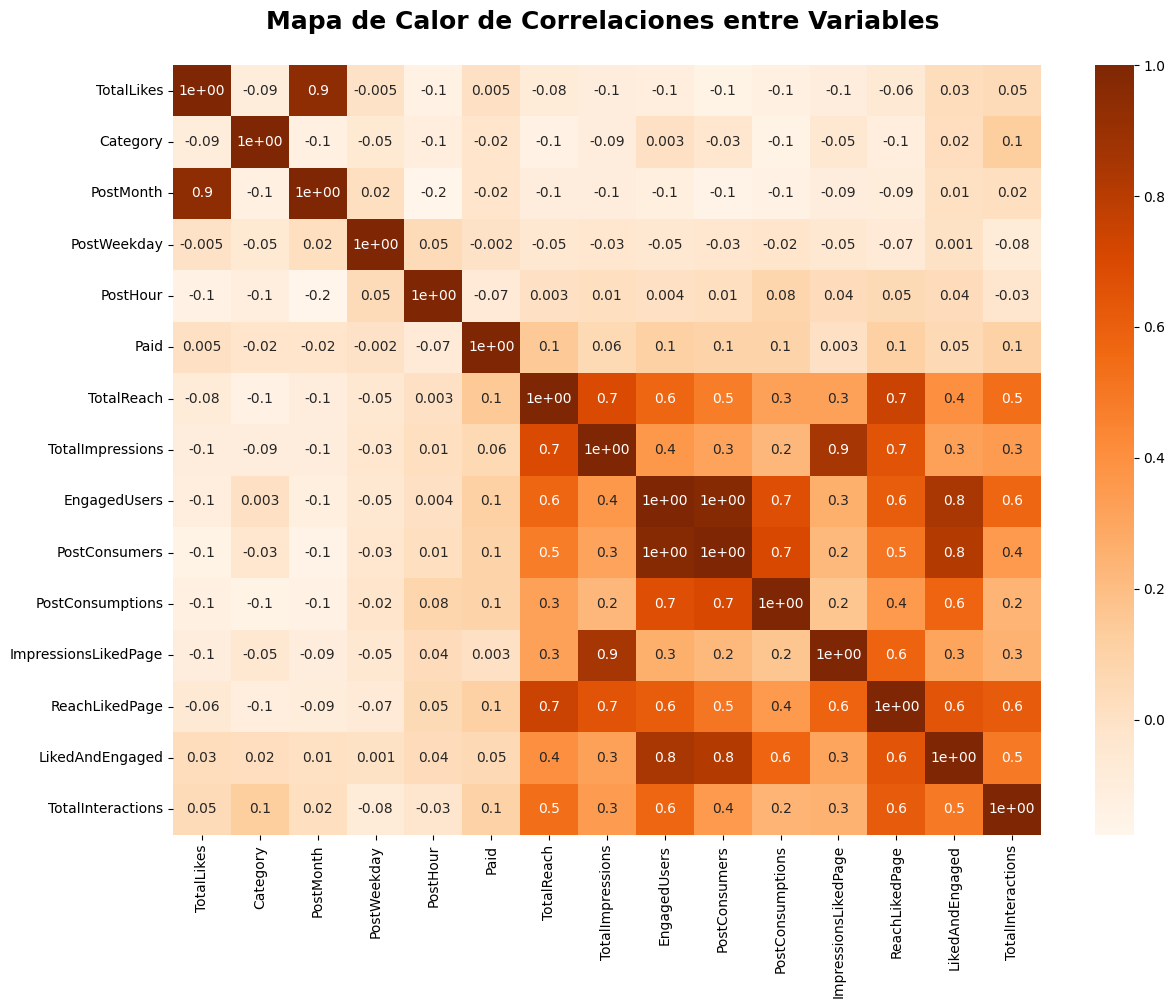

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(data.iloc[:, [0] + list(range(2, data.shape[1]))].corr(),
            annot=True, cmap="Oranges", fmt=".1")
plt.title('Mapa de Calor de Correlaciones entre Variables \n',
          fontweight = 'bold', fontsize = 18)
plt.show()

**Pregunta orientadora:** ¿Qué variables observas que tienen una correlación más fuerte con el total de interacciones?

**To Do**

### Gráfico de Dispersión (scatter plot)

Entre `Total Reach` y `Total Interactions`:

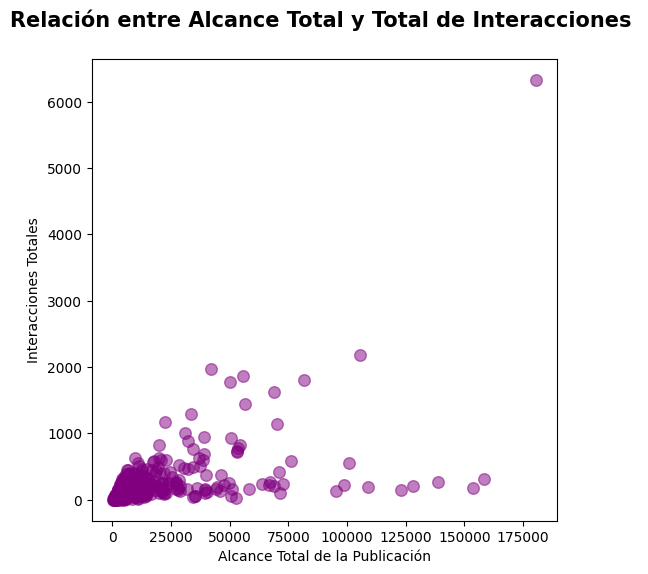

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(data['TotalReach'], data['TotalInteractions'], color='purple', s=70, alpha=0.5)
plt.xlabel('Alcance Total de la Publicación')
plt.ylabel('Interacciones Totales')
plt.title('Relación entre Alcance Total y Total de Interacciones \n',
          fontsize = 15, fontweight = 'bold')
plt.show()


### Gráfico de Violín (px.violin)

Entre `Total Reach` y `Post Type`

In [ ]:
fig = px.violin(data, y="TotalReach", x="PostType", color="PostType", box=True, points="all",
                title="Distribución de Tipo de Post vs ")
fig.show()


### Gráfico de Línea (line plot)

Entre `Post Hour` y `Total Interactions` por `Tipo de publicación`:

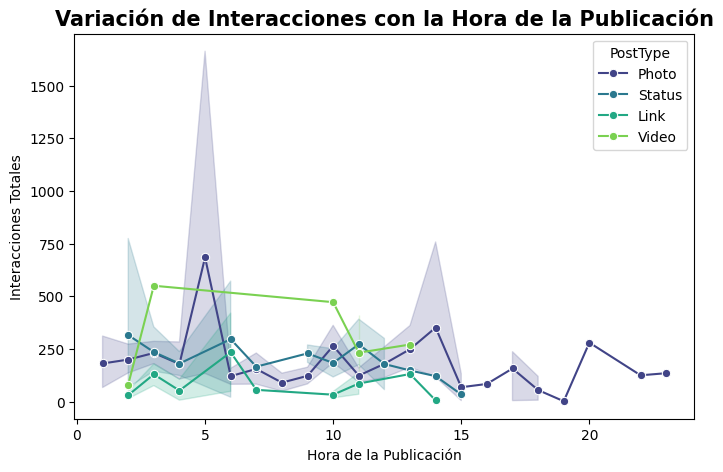

In [ ]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=data, x="PostHour", y="TotalInteractions", hue="PostType", marker='o', palette='viridis')
plt.xlabel('Hora de la Publicación')
plt.ylabel('Interacciones Totales')
plt.title('Variación de Interacciones con la Hora de la Publicación',
          fontsize = 15, fontweight = 'bold')
plt.show()


### Gráfico de Pares (sns.pairplot)

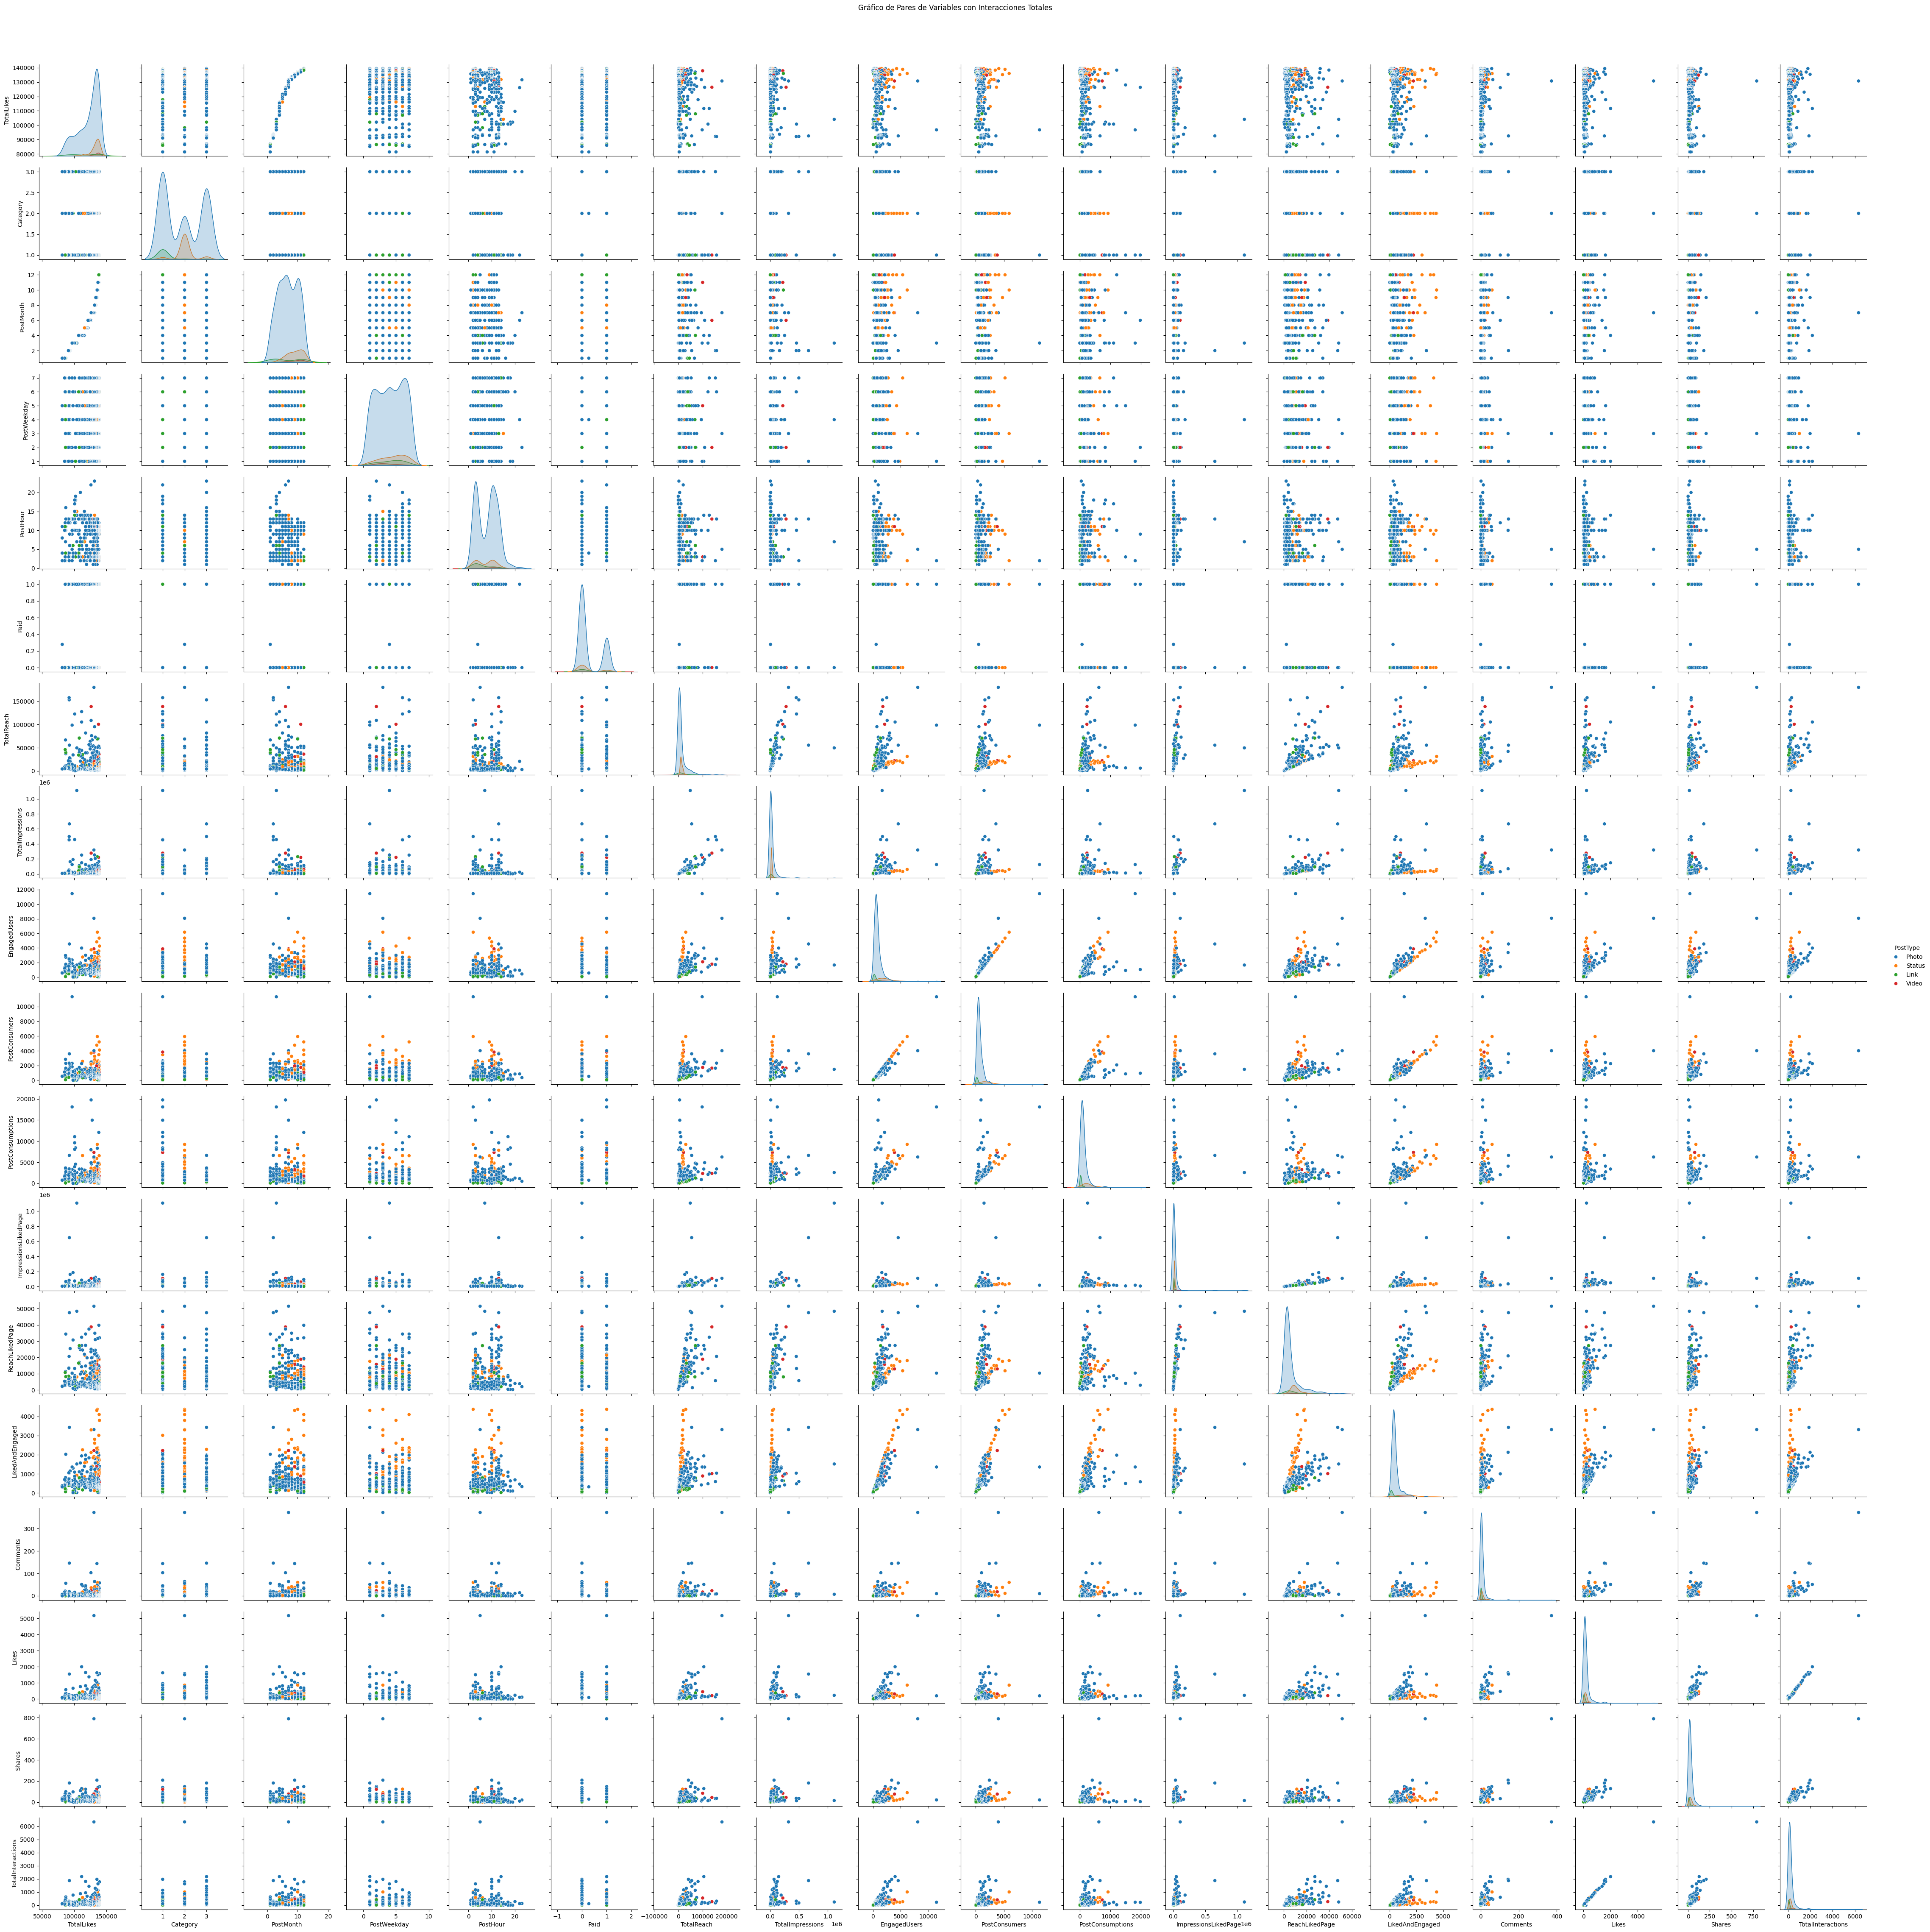

In [ ]:
# Pairplot con hue = Paid
sns.pairplot(data, hue='PostType')
plt.suptitle("Gráfico de Pares de Variables con Interacciones Totales", y=1.02)
plt.show()


## $\text{4. Preparación de X e y}$
Defina **X** como las variables independientes y **y** como la variable objetivo (Total Interacciones).

In [ ]:
# Separar las variables independientes (X) y dependientes (y)
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

print(X.shape, y.shape)

(500, 15) (500,)


In [ ]:
# Imprimir primera fila de X
print(X[:][0])

# Imprimir primeros 5 valores de y
print(y[0:6])

[139441 'Photo' 2 12 4 3 0.0 2752 5091 178 109 159 3078 1640 119]
[ 100  164   80 1777  393  186]


In [ ]:
# Como y es es string debemos convertir las categóricas a numéricas
# con onehot y columnTransformer

# Imputamos el column
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')

# Aplicamos fit_transform a y
X = ct.fit_transform(X)

# E imprimimos para saber cuáles son los nombres de las nuwvas columnas de y
print(ct.get_feature_names_out())

['encoder__x1_Link' 'encoder__x1_Photo' 'encoder__x1_Status'
 'encoder__x1_Video' 'remainder__x0' 'remainder__x2' 'remainder__x3'
 'remainder__x4' 'remainder__x5' 'remainder__x6' 'remainder__x7'
 'remainder__x8' 'remainder__x9' 'remainder__x10' 'remainder__x11'
 'remainder__x12' 'remainder__x13' 'remainder__x14']


## $\text{5. División de los Datos en Conjuntos de Entrenamiento y Prueba}$
Divida los datos en un conjunto de entrenamiento y uno de prueba, lo cual es importante para evaluar la precisión del modelo.

In [ ]:
# División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=47)

## $\text{6. Entrenamiento del Modelo}$
Entrene el modelo de regresión lineal Múltiple

In [ ]:
# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## $\text{7. Cálculo de Coeficientes}$
Una vez entrenado el modelo, obtenga los coeficientes $b_0$ (intercepto) y los $b_i$ (pendiente).

In [ ]:
# Obtener los coeficientes
coef_intercept = model.intercept_
coeficients = model.coef_

print("Intercepto:", coef_intercept)
print("\nCoeficientes:", coeficients)

Intercepto: -18.312177266673388

Coeficientes: [-5.74771333e-02 -3.19111913e+01 -5.93394464e+01  9.13081148e+01
  1.28977603e-03 -3.02926083e+00 -1.17142684e+01 -2.44391667e-01
 -1.52483491e+00 -9.45039910e+00 -1.69429401e-03  6.92279043e-04
  1.47336112e+00 -1.46417706e+00  6.19251539e-03 -4.85847043e-04
 -4.02730814e-03  8.09722418e-02]


## $\text{8. Predicciones y Evaluación del Modelo}$
Finalmente, use el modelo para hacer predicciones

In [ ]:
# Realizar predicciones
y_pred = model.predict(X_test)

# Calcular métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse}")
print(f"\nCoeficiente de determinación (R^2): {r2}")


Error cuadrático medio (MSE): 2687.078014049146

Coeficiente de determinación (R^2): 0.9079565824845474


Grafique las **predicciones** vs los **valores reales**

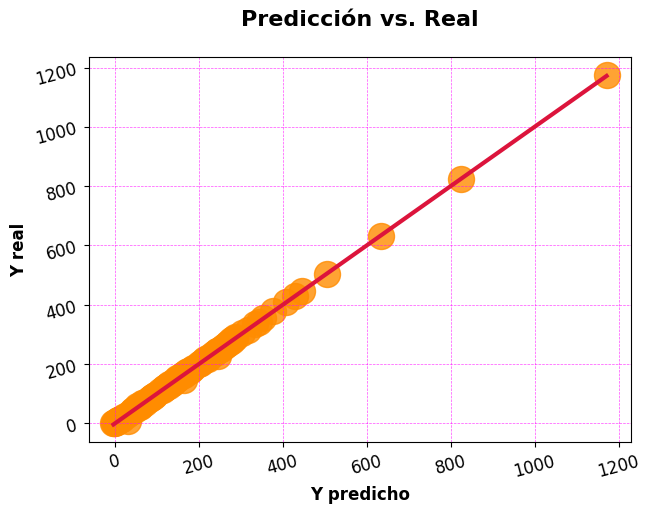

In [ ]:
# Comparar predicciones con valores reales en el gráfico

plt.figure(figsize=(7, 5))
sns.regplot(
    x=y_pred,
    y=y_test,
    scatter_kws={'color': 'darkorange', 's': 350},  # Tamaño de los puntos
    line_kws={'color': 'crimson', 'lw': 3}  # Grosor de la línea
)
plt.xlabel('Y predicho', fontsize=12, weight='bold')
plt.ylabel('Y real', fontsize=12, weight='bold')
plt.title('Predicción vs. Real\n', fontsize=16, weight='bold')
plt.grid(True, linestyle='--', linewidth=0.5, color='magenta', alpha=0.7)  # Grilla personalizada

# Ajuste de los valores en los ejes
plt.xticks(fontsize=12, rotation=15)
plt.yticks(fontsize=12, rotation=15)

plt.show()

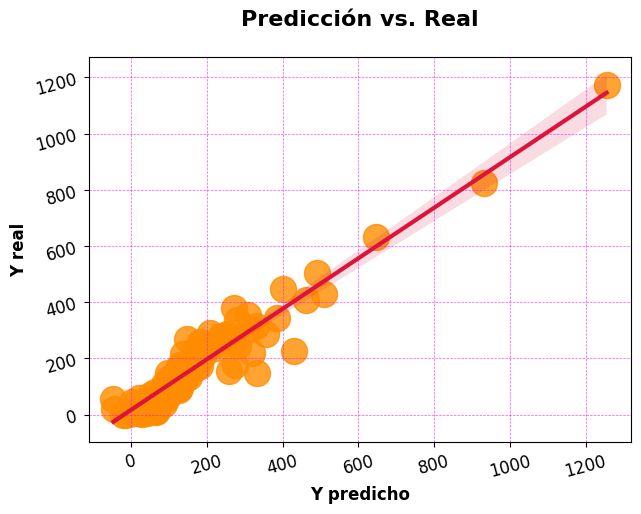

In [ ]:
# Comparar predicciones con valores reales en el gráfico

plt.figure(figsize=(7, 5))
sns.regplot(
    x=y_pred,
    y=y_test,
    scatter_kws={'color': 'darkorange', 's': 350},  # Tamaño de los puntos
    line_kws={'color': 'crimson', 'lw': 3}  # Grosor de la línea
)
plt.xlabel('Y predicho', fontsize=12, weight='bold')
plt.ylabel('Y real', fontsize=12, weight='bold')
plt.title('Predicción vs. Real\n', fontsize=16, weight='bold')
plt.grid(True, linestyle='--', linewidth=0.5, color='magenta', alpha=0.7)  # Grilla personalizada

# Ajuste de los valores en los ejes
plt.xticks(fontsize=12, rotation=15)
plt.yticks(fontsize=12, rotation=15)

plt.show()

## $\text{9. Conclusión}$

En este taller, analizamos datos de interacciones en Facebook para identificar patrones en el alcance y las interacciones de las publicaciones según su tipo, categoría y día de publicación.

Reflexiona sobre los resultados obtenidos, la precisión del modelo y cómo podrían usarse estos patrones para optimizar la estrategia de publicación en redes sociales.

**To Do**